# Predicting Category Basket Penetration with Logistic Regression

## Executive Summary

## Business problem

A grocery-and-general-merchandise retailer wants to grow its **premium fresh-prepared category** (a high-margin deli/ready-meal department). The merchandising team needs to know **which shoppers are likely to buy into the target category** so they can size the addressable audience, prioritize promotions, and set a propensity threshold for outbound offers. This is a classic **basket-penetration** question: model the probability that a shopper's basket includes the target category, given behavioral and program signals.

## Approach

We simulate 90 anonymized shopper records and fit a binary **PROC LOGISTIC** model for `Bought` (purchased the target category on the trip) using four candidate drivers:

- **Visit frequency** (trips per month) — engagement intensity
- **Prior-category spend** (dollars in the last quarter) — demonstrated category affinity
- **Promotion exposure** (received a targeted offer this cycle) — marketing lever
- **Loyalty tier** (Bronze / Silver / Gold) — program standing

The model reports **odds ratios with Wald confidence limits**, draws a **ROC curve** via the `ROC` statement, writes the ROC operating points to an **OUTROC= dataset** (the basis for threshold selection), and scores each shopper with a **predicted purchase probability** via the OUTPUT statement. We frame the model with **PROC FREQ** for the observed penetration rate by loyalty tier and **PROC MEANS** to contrast visit frequency and prior spend between buyers and non-buyers.

## What the run actually shows

Across the 90 trips, **53 baskets (58.9%)** included the target category, and penetration rises sharply with program standing: **Bronze 42.9%, Silver 64.5%, Gold 75.0%** (chi-square 6.69, *p* = 0.035). The fitted logistic model discriminates well — the ROC curve reaches an **AUC (c-statistic) of 0.84** — and every driver lands in the expected direction with a significant effect:

- **Loyalty tier — Gold** carries the largest pull (odds ratio **9.28** vs Bronze), **Silver 4.53**.
- **Promotion exposure** lifts the odds **4.47×** in a single cycle, the strongest *actionable* lever.
- **Visit frequency** odds ratio **1.54** per extra monthly trip; **prior-category spend** **1.012** per dollar.

The OUTROC operating points give a deployable cut-off: at a predicted-probability threshold of **0.62** (the Youden-optimal point) the model catches **75% of true buyers** while flagging only **22% of non-buyers**. Ranking shoppers by predicted probability then yields a ready-to-deploy targeting list for a ready-meal campaign.

## Data Sources

All data is **synthetic**, generated inline in the first DATA step (no external files, no network). One row per shopper trip, 90 rows total.

| Variable | Type | Description |
|----------|------|-------------|
| `ShopperID` | Num | Sequential shopper/trip identifier (1-90) |
| `LoyaltyTier` | Char | Loyalty program tier: `Bronze`, `Silver`, `Gold` |
| `VisitFreq` | Num | Trips per month (engagement intensity), ~2-12 |
| `PriorSpend` | Num | Prior-quarter spend in the target category (USD) |
| `PromoExposed` | Num | 1 if shopper received a targeted offer this cycle, else 0 |
| `Prob` | Num | Latent true purchase probability used to draw the outcome (illustrative) |
| `Bought` | Num | Outcome: 1 if the trip's basket included the target category, else 0 |

Penetration is engineered so higher visit frequency, higher prior spend, promotion exposure, and higher loyalty tier all raise the probability of buying into the category, giving the logistic model a realistic but learnable signal.

## Walkthrough

**Industry:** Retail and consumer goods  
**Goal:** Estimate the probability that a shopper buys into a target high-margin category (basket penetration) and quantify which drivers move that probability.

We will:

1. Generate a realistic synthetic shopper dataset (90 trips).
2. Profile the observed penetration rate by **loyalty tier** with `PROC FREQ`.
3. Contrast **visit frequency** and **prior spend** between buyers and non-buyers with `PROC MEANS`.
4. Fit a binary `PROC LOGISTIC` model with **odds ratios**, a **ROC curve**, an **OUTROC= dataset**, and **predicted probabilities**.
5. Rank shoppers by predicted propensity for a targeting list.
6. Turn the OUTROC operating points into a deployable propensity cut-off.
7. Interpret the levers and translate them into a targeting recommendation.

All data is synthetic and generated inline — nothing is read from disk or the network.

## 1. Generate synthetic shopper data

Each row is one shopper trip. We draw behavioral signals (visit frequency, prior-category spend), a marketing lever (promotion exposure), and program standing (loyalty tier), then build a latent log-odds so that every driver pushes penetration in a plausible direction. The binary outcome `Bought` is drawn from that probability with `rand('bernoulli', ...)`.

Note the Jenner-portable idioms: bounded uniforms are written as `LO + (HI-LO)*rand('uniform')`, and the row-generating `do` loop has an explicit `output;` so all 90 rows are written.

In [1]:
data shoppers;
    call streaminit(20240607);
    length LoyaltyTier $6;
    do ShopperID = 1 to 90;
        /* Loyalty tier: roughly 40% Bronze, 35% Silver, 25% Gold */
        u = rand('uniform');
        if u < 0.40 then do;
            LoyaltyTier = 'Bronze'; tierEff = 0.0;
        end;
        else if u < 0.75 then do;
            LoyaltyTier = 'Silver'; tierEff = 0.6;
        end;
        else do;
            LoyaltyTier = 'Gold';   tierEff = 1.3;
        end;

        /* Visit frequency: 2 to 12 trips per month */
        VisitFreq = round(2 + (12 - 2) * rand('uniform'), 1);

        /* Prior-quarter category spend: 0 to 180 USD, right-skewed */
        PriorSpend = round(180 * rand('uniform') ** 1.5, 0.01);

        /* Promotion exposure: ~45% received a targeted offer */
        PromoExposed = ifn(rand('uniform') < 0.45, 1, 0);

        /* Latent log-odds of buying into the target category */
        eta = -3.0
              + 0.22 * VisitFreq
              + 0.012 * PriorSpend
              + 0.85 * PromoExposed
              + tierEff;
        Prob = 1 / (1 + exp(-eta));

        Bought = rand('bernoulli', Prob);
        output;
    end;
    keep ShopperID LoyaltyTier VisitFreq PriorSpend PromoExposed Prob Bought;
run;

NOTE: DATA shoppers


NOTE: Wrote shoppers (90 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Observed penetration by loyalty tier

Before modeling, we look at the raw penetration rate (`Bought=1`) across loyalty tiers. The `TABLES LoyaltyTier*Bought` cross-tabulation with `NOPERCENT NOCUM` and a chi-square test shows whether tier alone is associated with buying into the category — the first cut at audience sizing.

                                     Observed Category Penetration by Loyalty Tier                                      

                                                   The FREQ Procedure

Table of LoyaltyTier by Bought

LoyaltyTier |         0 |         1 |      Total
------------+-----------+-----------+-----------
Bronze      |        20 |        15 |         35
------------+-----------+-----------+-----------
Gold        |         6 |        18 |         24
------------+-----------+-----------+-----------
Silver      |        11 |        20 |         31
------------+-----------+-----------+-----------
Total       |        37 |        53 |         90

Statistics for Table of LoyaltyTier by Bought

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 6.6943       0.0352
Likelihood Ratio Chi-Square               2 6.7870       0.0336

Cramer's V                    

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_loyaltytier_bought.spec.json
NOTE: PROC FREQ statement used.


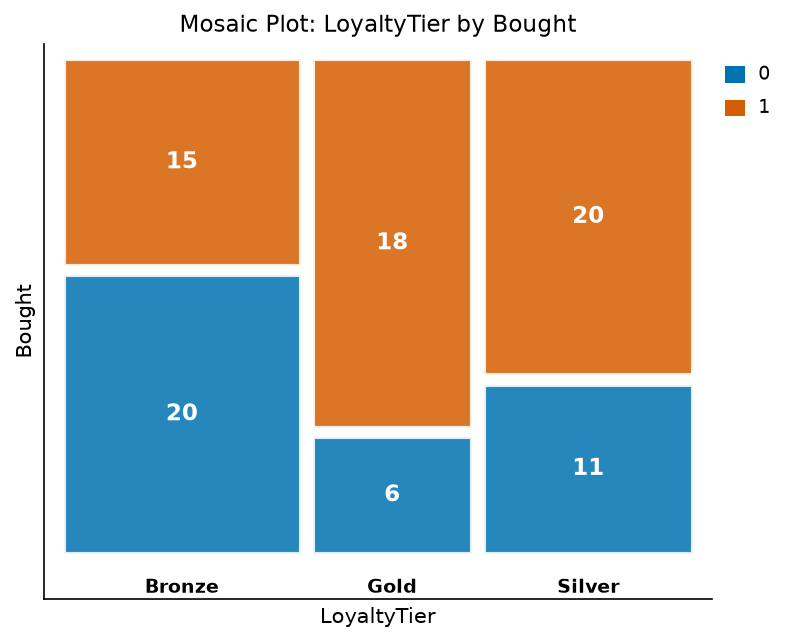

In [2]:
proc freq data=shoppers order=data;
    tables LoyaltyTier*Bought / nopercent nocum chisq;
    title 'Observed Category Penetration by Loyalty Tier';
run;

## 3. Visit frequency by purchase status

Do buyers simply visit more often? `PROC MEANS` contrasts visit frequency between shoppers who bought into the category and those who did not. A wide gap suggests engagement is a strong standalone lever; a narrow one points to affinity or promotion as the real driver.

In [3]:
proc means data=shoppers n mean std min max maxdec=2;
    class Bought;
    var VisitFreq PriorSpend;
    title 'Visit Frequency and Prior Spend by Purchase Status';
run;

                                   Visit Frequency and Prior Spend by Purchase Status                                   

                                                  The MEANS Procedure

                                             Analysis Variable : VisitFreq

        Bought            N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        0                    37           5.76           2.67           2.00          10.00
        1                    53           7.92           2.61           2.00          12.00
        -----------------------------------------------------------------------------------

                                             Analysis Variable : PriorSpend

        Bought            N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        0

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Logistic model of basket penetration

Now we fit the binary logistic model. `LoyaltyTier` enters as a CLASS effect with reference-cell coding (`PARAM=REF`, reference `Bronze`), and the continuous drivers enter directly. Key model-statement options:

- `EVENT='1'` — model the probability that `Bought=1` (the purchase event).
- `CLODDS=WALD` — Wald confidence limits for the odds ratios.
- `RSQUARE` — the generalized (Cox-Snell) and max-rescaled R-square fit measures.
- `OUTROC=roc` — write the ROC operating points (sensitivity / 1-specificity at each cut-off) to a dataset we reuse in Section 6.

The `ROC` statement draws the ROC curve and reports its area (AUC / c-statistic), and the `OUTPUT` statement scores every shopper with a predicted purchase probability (`PredProb`). Because `PROC LOGISTIC` is an interactive (RUN-group) procedure, we close the step with `run;` then `quit;` so the kernel flushes its output in this cell.

Read the output top-down: the **Maximum Likelihood Estimates** give the log-odds coefficients (all positive here), the **Odds Ratio Estimates** translate them to multiplicative effects with Wald limits, and the **ROC curve** shows how well the predicted probabilities separate buyers from non-buyers.

                                   Visit Frequency and Prior Spend by Purchase Status                                   

                                     
---------------------------  --------
Number of Observations Read        90
Number of Observations Used        90

            Response Profile            
   Probability modeled is Bought='1'    

Ordered Value  Bought    Total Frequency
-------------  --------  ---------------
            1  0                      37
            2  1                      53

         Class Level Information         

Class          Levels  Values            
-----------  --------  ------------------
LoyaltyTier         3  Bronze Gold Silver

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: Bought

Criterion     Value
---------  --------
AIC          99.321
-2 Log L     87.321
SC          114.319

                 

NOTE: PROC LOGISTIC data=shoppers

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: Output dataset scored written with 90 observations.
NOTE: OUTROC dataset roc written with 91 points.
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: ODS plot written: logistic_roc.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json


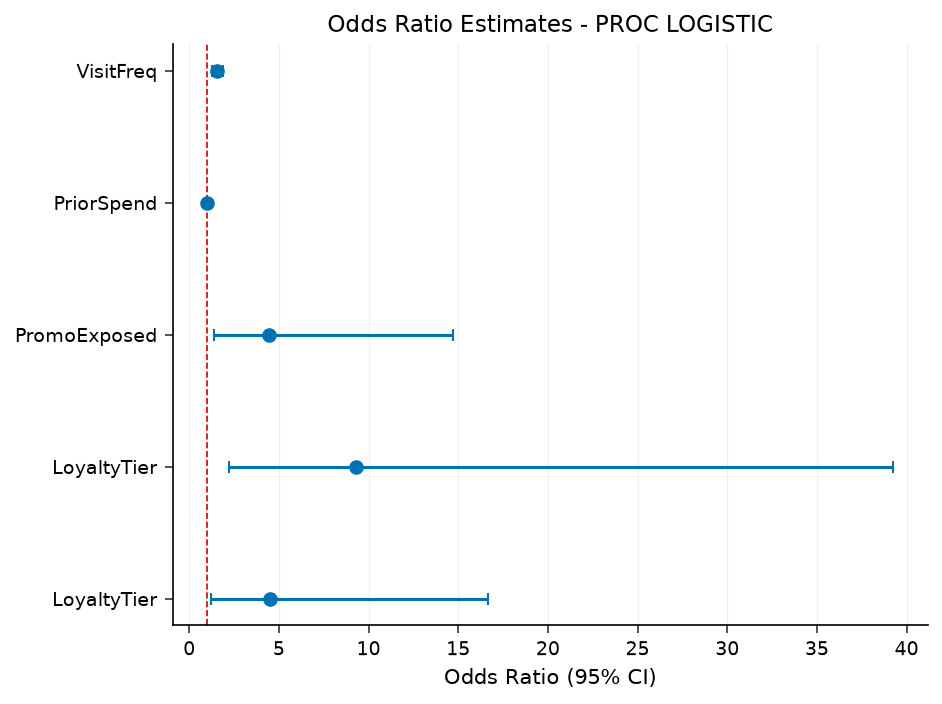

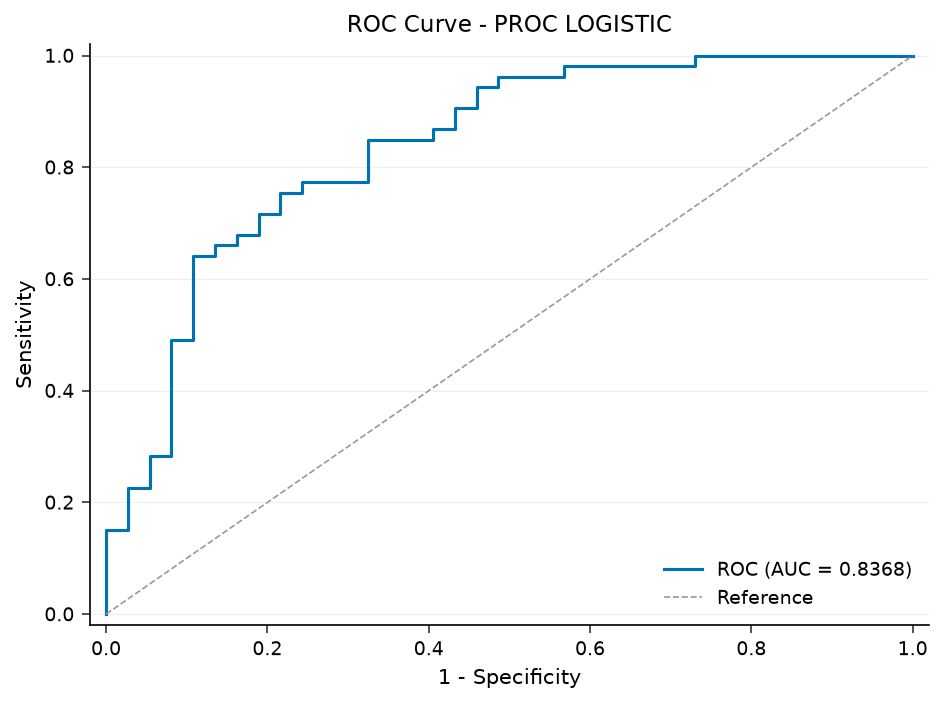

In [4]:
proc logistic data=shoppers;
    class LoyaltyTier (ref='Bronze') / param=ref;
    model Bought(event='1') = VisitFreq PriorSpend PromoExposed LoyaltyTier
          / clodds=wald rsquare outroc=roc;
    output out=scored predicted=PredProb;
    roc;
    title 'Logistic Model: Probability of Category Purchase';
run;
quit;

## 5. Rank shoppers by predicted propensity

The scored dataset gives each shopper a model-based purchase probability. Ranking by `PredProb` is exactly how a campaign team would select an outreach audience: pick a cut-off (say the top quartile) and target those shoppers with a ready-meal offer. We show the highest-propensity shoppers and summarize the predicted-probability distribution.

In [5]:
proc sort data=scored out=ranked;
    by descending PredProb;
run;

proc print data=ranked(obs=10) noobs;
    var ShopperID LoyaltyTier VisitFreq PriorSpend PromoExposed PredProb Bought;
    format PredProb 6.3;
    title 'Top 10 Shoppers by Predicted Penetration Propensity';
run;

proc means data=scored n mean std min p25 median p75 max maxdec=3;
    var PredProb;
    title 'Distribution of Predicted Purchase Probability';
run;

                                  Top 10 Shoppers by Predicted Penetration Propensity                                   

SHOPPERID  LOYALTYTIER  VISITFREQ  PRIORSPEND  PROMOEXPOSED  PREDPROB  BOUGHT
       62  Gold                10       91.56             1     0.981       1
       43  Gold                10       74.83             1     0.977       1
       87  Gold                11       22.04             1     0.972       1
       67  Silver              12      163.72             0     0.970       1
       75  Silver               8      167.49             1     0.964       1
       12  Gold                 9       57.01             1     0.958       1
       72  Silver               9      110.72             1     0.955       1
       88  Gold                 7      120.46             1     0.953       1
       51  Silver               8      142.78             1     0.953       0
       61  Silver              11      122.87             0     0.928       1

... 80 more observa

NOTE: PROC SORT data=scored

NOTE: Read 90 rows from scored.
NOTE: Wrote ranked (90 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=ranked

NOTE: PROC PRINT completed: 10 observations printed, 7 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 6. The ROC dataset and a targeting cut-off

The `OUTROC=roc` dataset records every candidate probability cut-off (`_PROB_`) with its sensitivity (`_SENSIT_`, the share of true buyers caught) and its false-positive rate (`_1MSPEC_`, 1 - specificity). This is exactly the curve plotted above. To turn it into a campaign rule, we add Youden's J (`_SENSIT_ - _1MSPEC_`) and read off the cut-off that maximizes the separation between buyers and non-buyers — the operating point a merchandising team would adopt to balance reach against wasted offers.

In [6]:
/* Add Youden's J to the OUTROC points and find the best cut-off */
data roc_j;
    set roc;
    YoudenJ = _SENSIT_ - _1MSPEC_;
run;

proc sort data=roc_j out=roc_sorted;
    by descending YoudenJ;
run;

proc print data=roc_sorted(obs=5) noobs;
    var _PROB_ _SENSIT_ _1MSPEC_ YoudenJ;
    format _PROB_ _SENSIT_ _1MSPEC_ YoudenJ 7.4;
    title 'Top Operating Points by Youden''s J (OUTROC=roc)';
run;

                                    Top Operating Points by Youden's J (OUTROC=roc)                                     

_PROB_  _SENSIT_  _1MSPEC_  YOUDENJ
0.6190    0.7547    0.2162   0.5385
0.7258    0.6415    0.1081   0.5334
0.6081    0.7736    0.2432   0.5303
0.6405    0.7170    0.1892   0.5278
0.6700    0.6604    0.1351   0.5252

... 86 more observations (showing 5 of 91)



NOTE: DATA roc_j


NOTE: Read 91 rows from roc.
NOTE: Wrote roc_j (91 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=roc_j

NOTE: Read 91 rows from roc_j.
NOTE: Wrote roc_sorted (91 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=roc_sorted

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


## 7. Interpretation and recommendation

**Reading the model.** The model fits well for a behavioral propensity model: generalized R-square **0.319** (max-rescaled **0.430**) and a ROC **AUC of 0.84**. Every coefficient is positive and significant (all *p* < 0.025), and the odds ratios (with Wald limits) translate each driver into a multiplicative effect on the odds of buying into the target category. In the odds-ratio forest plot, the two `LoyaltyTier` rows are, in order, **Gold** (the wide upper interval) and **Silver** — both reference Bronze.

- **Loyalty tier** is the strongest contrast: **Gold** shoppers have **9.28×** the odds of penetration vs Bronze (95% Wald CI 2.19–39.25) and **Silver 4.53×** (1.23–16.68). This confirms the `PROC FREQ` gradient (Bronze 42.9% → Silver 64.5% → Gold 75.0%) on an odds scale, holding the other drivers fixed.
- **Promotion exposure** is the fastest-acting lever a campaign actually controls: a targeted offer multiplies the odds **4.47×** (1.36–14.69) in a single cycle.
- **Visit frequency** and **prior-category spend** are positive, continuous levers — each extra monthly trip raises the odds **1.54×** (1.25–1.91) and each extra dollar of prior spend **1.012×** (1.002–1.023). The `PROC MEANS` contrast echoes this: buyers average **7.9** trips/month vs **5.8** for non-buyers, and **$75** of prior spend vs **$50**. These reflect engagement and demonstrated affinity, which a retailer can grow but only over time.

**Audience sizing.** The loyalty-tier penetration table sizes the natural audience: Gold members already buy into the category at the highest rate (75%), so incremental promotion there yields less lift, while Bronze/Silver shoppers with high predicted probability are the efficient growth target.

**Operational use.** The `OUTROC=roc` dataset and the predicted probabilities let the team choose a propensity threshold that balances reach against offer cost. The Youden-optimal cut-off (Section 6) is a predicted probability of **0.62**, which catches **75.5%** of true buyers while flagging only **21.6%** of non-buyers. Ranking shoppers by `PredProb` (Section 5) produces a ready-to-deploy targeting list: the top-propensity shoppers all score above **0.92** and are overwhelmingly Gold and Silver members exposed to promotion. The actionable play is to send the ready-meal offer to high-propensity shoppers who have **not** yet bought into the category, where the marketing dollar buys the most incremental penetration.

**Caveats.** This notebook uses synthetic data with a known data-generating process, so the recovered coefficients track the planted signal and the AUC is optimistic relative to a real hold-out. On real data, validate on a hold-out sample, monitor calibration of `PredProb`, and re-estimate as the assortment and promotion calendar change.